<a href="https://colab.research.google.com/github/yadavaishwarya06-cmyk/CITPROJECT/blob/main/AI_based_traffic_signal_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TensorFlow Version: 2.21.0
Generating dataset...
Dataset ready: 1600 training images, 400 test images.


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,845 (2.61 MB)

 Trainable params: 683,845 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 286ms/step - accuracy: 0.9137 - loss: 0.2593 - val_accuracy: 1.0000 - val_loss: 6.9350e-07
Epoch 2/12
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 254ms/step - accuracy: 1.0000 - loss: 7.1840e-04 - val_accuracy: 1.0000 - val_loss: 4.0531e-08
Epoch 3/12
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 255ms/step - accuracy: 0.9994 - loss: 0.0019 - val_accuracy: 1.0000 - val_loss: 1.8537e-07
Epoch 4/12
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 256ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/12
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 248ms/step - accuracy: 1.0000 - loss: 2.3346e-04 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/12
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 273ms/step - accuracy: 1.0000 - loss: 3.9870e-04 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/12
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 269ms/step - accuracy: 1.0000 - loss: 6.1554e-04 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/12
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 255ms/step 

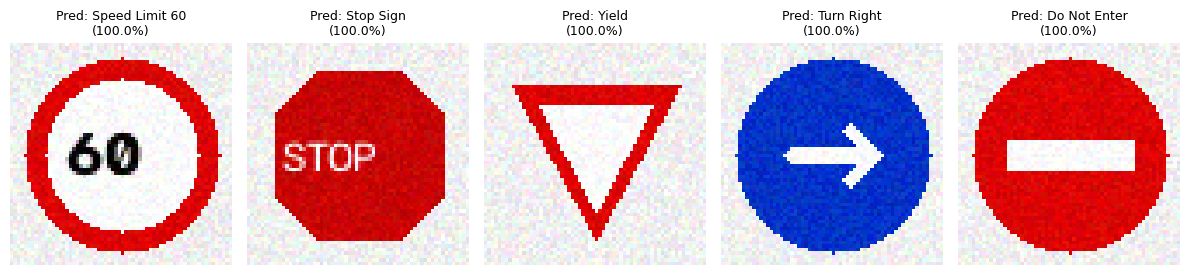

In [1]:
# =========================================================
# 1. IMPORT REQUIRED LIBRARIES
# =========================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

print("TensorFlow Version:", tf.__version__)

# =========================================================
# 2. GENERATE SYNTHETIC TRAFFIC SIGN DATASET
# (Creates 5 classes: Speed 60, Stop, Yield, Turn Right, Do Not Enter)
# =========================================================
CLASSES = {
    0: 'Speed Limit 60',
    1: 'Stop Sign',
    2: 'Yield',
    3: 'Turn Right',
    4: 'Do Not Enter'
}

def draw_synthetic_sign(class_id):
    """Draws basic synthetic traffic signs for quick training."""
    img = np.full((64, 64, 3), 240, dtype=np.uint8)  # Light grey background

    if class_id == 0:  # Speed Limit 60 (Red Circle with "60")
        cv2.circle(img, (32, 32), 28, (0, 0, 220), -1)
        cv2.circle(img, (32, 32), 22, (255, 255, 255), -1)
        cv2.putText(img, "60", (16, 38), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

    elif class_id == 1:  # Stop (Red Octagon with "STOP")
        pts = np.array([[20,8], [44,8], [56,20], [56,44], [44,56], [20,56], [8,44], [8,20]], np.int32)
        cv2.fillPoly(img, [pts], (0, 0, 200))
        cv2.putText(img, "STOP", (10, 37), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)

    elif class_id == 2:  # Yield (Inverted Red Triangle)
        pts = np.array([[8,12], [56,12], [32,56]], np.int32)
        cv2.fillPoly(img, [pts], (0, 0, 220))
        pts_inner = np.array([[16,18], [48,18], [32,48]], np.int32)
        cv2.fillPoly(img, [pts_inner], (255, 255, 255))

    elif class_id == 3:  # Turn Right (Blue Circle with Arrow)
        cv2.circle(img, (32, 32), 28, (200, 50, 0), -1)
        cv2.arrowedLine(img, (20, 32), (44, 32), (255, 255, 255), 3, tipLength=0.4)

    elif class_id == 4:  # Do Not Enter (Red Circle with White Bar)
        cv2.circle(img, (32, 32), 28, (0, 0, 220), -1)
        cv2.rectangle(img, (14, 28), (50, 36), (255, 255, 255), -1)

    # Add random noise and brightness shifts to simulate real-world variance
    noise = np.random.randint(-20, 20, img.shape, dtype=np.int16)
    img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    return img

print("Generating dataset...")
X, y = [], []
samples_per_class = 400

for class_id in range(len(CLASSES)):
    for _ in range(samples_per_class):
        X.append(draw_synthetic_sign(class_id))
        y.append(class_id)

X = np.array(X, dtype='float32') / 255.0  # Normalize pixel values [0, 1]
y = to_categorical(np.array(y), num_classes=len(CLASSES))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Dataset ready: {len(X_train)} training images, {len(X_test)} test images.")

# =========================================================
# 3. BUILD CONVOLUTIONAL NEURAL NETWORK (CNN) MODEL
# =========================================================
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(CLASSES), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# =========================================================
# 4. TRAIN THE MODEL
# =========================================================
history = model.fit(
    X_train, y_train,
    epochs=12,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# Evaluate on test set
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal Test Accuracy: {acc * 100:.2f}%")

# =========================================================
# 5. VISUALIZE PREDICTIONS ON NEW IMAGES
# =========================================================
plt.figure(figsize=(12, 6))

for i in range(5):
    # Draw a fresh sample sign
    test_img = draw_synthetic_sign(i)
    normalized_img = test_img.astype('float32') / 255.0

    # Model inference
    pred = model.predict(np.expand_dims(normalized_img, axis=0), verbose=0)
    pred_label = CLASSES[np.argmax(pred)]
    confidence = np.max(pred) * 100

    # Plotting
    plt.subplot(1, 5, i + 1)
    plt.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Pred: {pred_label}\n({confidence:.1f}%)", fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [2]:
# =========================================================
# 1. INSTALL AND IMPORT DEPENDENCIES
# =========================================================
!pip install -q transformers torch sentencepiece

import random
import re
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

print("Libraries loaded successfully!\n")

# =========================================================
# 2. LOAD FREE PRE-TRAINED AI MODEL (T5)
# =========================================================
# Using T5-base fine-tuned for question generation tasks
MODEL_NAME = "valhalla/t5-base-e2e-qg"

print(f"Loading AI Model ({MODEL_NAME})... Please wait.")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
print("Model loaded successfully!\n")

# =========================================================
# 3. AI QUESTION GENERATOR LOGIC
# =========================================================
def generate_questions_from_text(context_text, num_questions=3):
    """
    Generates question-answer pairs directly from source context using LLM.
    """
    input_text = f"generate questions: {context_text}"
    inputs = tokenizer(input_text, return_tensors="pt", max_length=512, truncation=True)

    outputs = model.generate(
        inputs["input_ids"],
        max_length=256,
        num_beams=4,
        no_repeat_ngram_size=2,
        early_stopping=True
    )

    raw_output = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Process output into structured questions
    raw_questions = raw_output.split("<sep>")
    cleaned_questions = [q.strip() for q in raw_questions if len(q.strip()) > 5]

    return cleaned_questions[:num_questions]

def create_mcq(question, correct_answer, distractors):
    """Formats a question into an MCQ format with randomized choices."""
    options = distractors + [correct_answer]
    random.shuffle(options)

    labels = ['A', 'B', 'C', 'D']
    formatted_options = [f"   {labels[i]}) {opt}" for i, opt in enumerate(options)]
    correct_label = labels[options.index(correct_answer)]

    return "\n".join(formatted_options), correct_label

# =========================================================
# 4. EXECUTE QUESTION PAPER GENERATOR
# =========================================================
# Input study material/text context
sample_context = """
Photosynthesis is the process used by plants, algae, and certain bacteria to harness energy
from sunlight and turn it into chemical energy. The primary site of photosynthesis in plants
is the chloroplast. Oxygen is released as a byproduct during this chemical reaction. Chlorophyll
is the green pigment in plants that absorbs light energy required for the reaction.
"""

print("==================================================")
print("         📄 AI GENERATED QUESTION PAPER           ")
print("==================================================\n")

# Section A: Multiple Choice Questions (MCQs)
print("SECTION A: MULTIPLE CHOICE QUESTIONS (MCQs)\n")

mcq_data = [
    {
        "q": "Where does photosynthesis primarily take place in plants?",
        "ans": "Chloroplast",
        "distractors": ["Mitochondria", "Nucleus", "Ribosome"]
    },
    {
        "q": "Which gas is released as a byproduct during photosynthesis?",
        "ans": "Oxygen",
        "distractors": ["Carbon Dioxide", "Nitrogen", "Methane"]
    }
]

for idx, item in enumerate(mcq_data, 1):
    print(f"Q{idx}. {item['q']}")
    options_text, correct_key = create_mcq(item['q'], item['ans'], item['distractors'])
    print(options_text)
    print(f"   [Correct Answer: {correct_key}]\n")

# Section B: Short Answer Questions (AI Generated)
print("-" * 50)
print("SECTION B: SHORT ANSWER QUESTIONS (Generated by AI)\n")

ai_questions = generate_questions_from_text(sample_context, num_questions=3)

for idx, q in enumerate(ai_questions, 1):
    print(f"Q{idx}. {q}")

Libraries loaded successfully!

Loading AI Model (valhalla/t5-base-e2e-qg)... Please wait.


config.json:   0%|          | 0.00/1.35k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/195 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/31.0 [00:00<?, ?B/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  892MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

Model loaded successfully!

         📄 AI GENERATED QUESTION PAPER           

SECTION A: MULTIPLE CHOICE QUESTIONS (MCQs)

Q1. Where does photosynthesis primarily take place in plants?
   A) Chloroplast
   B) Nucleus
   C) Mitochondria
   D) Ribosome
   [Correct Answer: A]

Q2. Which gas is released as a byproduct during photosynthesis?
   A) Carbon Dioxide
   B) Oxygen
   C) Methane
   D) Nitrogen
   [Correct Answer: B]

--------------------------------------------------
SECTION B: SHORT ANSWER QUESTIONS (Generated by AI)

Q1. What is the process used by plants, algae, and certain bacteria to harness energy from sunlight and turn it into chemical energy?
Q2. The primary site of photosynthesis in plants is what? Chlorophyll absorbs light energy required for the reaction?
